# S2 local descent methods

In [1]:
using Plots, LinearAlgebra

## line search

In [2]:
function bracket_minimum(f, x=0; s=1e-2, k=2.0)
    a, ya = x, f(x)
    b, yb = a + s, f(a + s)
    if yb > ya
        a, b = b, a
        ya, yb = yb, ya
        s = -s
    end
    while true
        c, yc = b + s, f(b + s)
        if yc > yb
            return a < c ? (a, c) : (c, a)
        end
        a, ya, b, yb = b, yb, c, yc
        s *= k
    end
end

bracket_minimum (generic function with 2 methods)

In [3]:
function line_search(f, x, d)
    objective = α -> f(x + α * d)
    a, b = bracket_minimum(objective)
    α = minimize(objective, a, b)
    return x + α * d
end

line_search (generic function with 1 method)

In [4]:
f(x) = (x - 3)^2 + 1 
line_search(f, 1,-1)

UndefVarError: UndefVarError: `minimize` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
using Pkg
Pkg.add("Optim")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [6]:
using Optim

In [10]:
function line_search(f, x, d)
  objective = α -> f(x + α * d)
  a, b = bracket_minimum(objective)

  # Use Optim.jl to minimize the objective function
  result = optimize(objective, a, b, Brent())  # Brent's method for 1D minimization
  α = Optim.minimizer(result)  # Extract the minimizing α value

  return x + α * d, α
end

line_search (generic function with 1 method)

In [13]:

f(x) = (x - 3)^2 + 1  # A simple quadratic function
x = 10.0  # Starting point
d = -1.0  # Search direction

result = line_search(f, x, d)
println(result)  # Should be close to 3.0

(3.0, 7.0)


In [25]:
@time begin
f(x) = (x - 3)^2 + 1  # A simple quadratic function
x = 8.0  # Starting point
d = -1.0  # Search direction

result = line_search(f, x, d)
println(result)  # Should be close to 3.0
end

(3.0, 5.0)
  0.040783 seconds (88.82 k allocations: 4.711 MiB, 27.10% gc time, 99.50% compilation time: 100% of which was recompilation)


In [26]:
using Pkg
Pkg.add("BenchmarkTools")


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [27]:
using BenchmarkTools

In [28]:
@benchmark begin
    f(x) = (x - 3)^2 + 1  # A simple quadratic function
    x = 8.0  # Starting point
    d = -1.0  # Search direction
    
    result = line_search(f, x, d)
    # println(result)  # Should be close to 3.0
    end

BenchmarkTools.Trial: 10000 samples with 695 evaluations per sample.
 Range (min … max):  181.295 ns …  12.080 μs  ┊ GC (min … max): 0.00% … 98.07%
 Time  (median):     186.030 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   201.084 ns ± 209.344 ns  ┊ GC (mean ± σ):  6.36% ±  6.42%

     ▇█▇▄▁▂                                                      
  ▁▃████████▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  181 ns           Histogram: frequency by time          217 ns <

 Memory estimate: 208 bytes, allocs estimate: 5.

In [29]:
results=@benchmark begin
    f(x) = (x - 3)^2 + 1  # A simple quadratic function
    x = 8.0  # Starting point
    d = -1.0  # Search direction
    
    result = line_search(f, x, d)
    # println(result)  # Should be close to 3.0
    end

BenchmarkTools.Trial: 10000 samples with 676 evaluations per sample.
 Range (min … max):  183.124 ns …  14.409 μs  ┊ GC (min … max): 0.00% … 98.49%
 Time  (median):     189.164 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   202.463 ns ± 232.721 ns  ┊ GC (mean ± σ):  5.46% ±  5.40%

    ▂▄▅▄▆█▇▃                                                     
  ▁▃█████████▇█▇▇▇▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  183 ns           Histogram: frequency by time          221 ns <

 Memory estimate: 208 bytes, allocs estimate: 5.

In [30]:
results

BenchmarkTools.Trial: 10000 samples with 676 evaluations per sample.
 Range (min … max):  183.124 ns …  14.409 μs  ┊ GC (min … max): 0.00% … 98.49%
 Time  (median):     189.164 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   202.463 ns ± 232.721 ns  ┊ GC (mean ± σ):  5.46% ±  5.40%

    ▂▄▅▄▆█▇▃                                                     
  ▁▃█████████▇█▇▇▇▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  183 ns           Histogram: frequency by time          221 ns <

 Memory estimate: 208 bytes, allocs estimate: 5.

In [31]:
mean(results)


BenchmarkTools.TrialEstimate: 
  time:             202.463 ns
  gctime:           11.052 ns (5.46%)
  memory:           208 bytes
  allocs:           5

In [32]:
median(results)

BenchmarkTools.TrialEstimate: 
  time:             189.164 ns
  gctime:           0.000 ns (0.00%)
  memory:           208 bytes
  allocs:           5

> example
>  $f(x_1,x_2,x_3)=x_1^2+(x_2-1)^2+(x_3-2)^2$  
> $x=(1,2,-3)$ direction $d=(-1,-1,1)$

In [33]:
x = [1,2,-3]
d = [-1,-1,1]
f(x)=x[1]^2+(x[2]-1)^2+(x[3]-2)^2
objective = α -> f(x .+ α * d)



#24 (generic function with 1 method)

In [34]:
result = optimize(objective, -1, 1, Brent())  # Brent's method for 1D minimization
α = Optim.minimizer(result)

0.9999999778768225

In [35]:
x .+ α * d, f(x .+ α * d)

([2.2123177512156644e-8, 1.0000000221231775, -2.0000000221231775], 16.000000176985424)

## approximate line search

In [36]:
function backtracking_line_search(f, ∇f, x, d, α; p=0.5, β=1e-4)
    y, g = f(x), ∇f(x)
    while f(x + α * d) > y + β * α * dot(g , d)
        α *= p
        println(α," ",f(x + α * d), " ", x + α * d )
    end
    α
end

backtracking_line_search (generic function with 1 method)

In [37]:
f_obj = x -> x[1]^2+x[1]* x[2]+x[2]^2
∇f_obj = x-> (2x[2]+x[2], x[1]+2x[2])

#29 (generic function with 1 method)

In [38]:
x = [1,2]
d = [-1,-1]
α = 10
σ = 0.9
f_obj(x)

7

In [39]:
backtracking_line_search(f_obj, ∇f_obj, x, d, α)

5.0 37.0 [-4.0, -3.0]
2.5 3.25 [-1.5, -0.5]


2.5

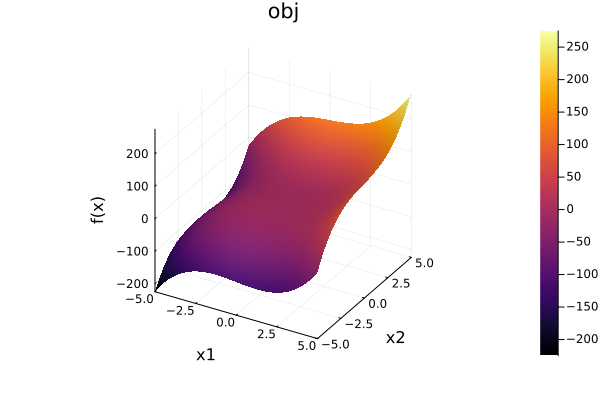

In [47]:
using Plots

f_obj = x -> x[1]^3+x[1]* x[2]+x[2]^3

# Define a grid of (x1, x2) values
x1 = range(-5, 5, length=100)
x2 = range(-5, 5, length=100)

# Compute z values for the grid
z = [f_obj([x, y]) for x in x1, y in x2]

# Plot the surface
surface(x1, x2, z, xlabel="x1", ylabel="x2", zlabel="f(x)", title="obj")


In [41]:
using Pkg
Pkg.add("GLMakie")

   Resolving package versions...
   Installed RoundingEmulator ──────────── v0.2.1
   Installed SignedDistanceFields ──────── v0.4.0
   Installed EarCut_jll ────────────────── v2.2.4+0
   Installed ModernGL ──────────────────── v1.1.8
   Installed FilePaths ─────────────────── v0.9.0
   Installed AdaptivePredicates ────────── v1.2.0
   Installed BaseDirs ──────────────────── v1.3.2
   Installed GLMakie ───────────────────── v0.13.8
   Installed TriplotBase ───────────────── v0.1.0
   Installed isoband_jll ───────────────── v0.2.3+0
   Installed PolygonOps ────────────────── v0.1.2
   Installed GridLayoutBase ────────────── v0.11.2
   Installed OpenBLASConsistentFPCSR_jll ─ v0.3.29+0
   Installed FreeType ──────────────────── v4.1.1
   Installed Automa ────────────────────── v1.1.0
   Installed Isoband ───────────────────── v0.1.1
   Installed FreeTypeAbstraction ───────── v0.10.8
   Installed Extents ───────────────────── v0.1.6
   Installed Packing ───────────────────── v0.5.1
   Inst

In [42]:
using Pkg
Pkg.add("WGLMakie")

   Resolving package versions...
   Installed WidgetsBase ─ v0.1.4
   Installed MsgPack ───── v1.2.1
   Installed Hyperscript ─ v0.0.5
   Installed Deno_jll ──── v1.33.4+0
   Installed ThreadPools ─ v2.1.1
   Installed WGLMakie ──── v0.13.8
   Installed Bonito ────── v4.1.12
    Updating `~/.julia/environments/v1.11/Project.toml`
  [276b4fcb] + WGLMakie v0.13.8
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [824d6782] + Bonito v4.1.12
  [47d2ed2b] + Hyperscript v0.0.5
  [99f44e22] + MsgPack v1.2.1
  [b189fb0b] + ThreadPools v2.1.1
  [276b4fcb] + WGLMakie v0.13.8
  [eead4739] + WidgetsBase v0.1.4
⌅ [04572ae6] + Deno_jll v1.33.4+0
        Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated -m`
Precompiling project...
   1659.2 ms  ✓ WidgetsBase
   1725.3 ms  ✓ Deno_jll
   2077.5 ms  ✓ Hyperscript
   2087.2 ms  ✓ MsgPack
   2020.0 ms  ✓ ThreadPools
   6053.6 ms  ✓ Bonito
 107807.3

In [45]:
using WGLMakie

f_obj = x -> x[1]^3 + x[1] * x[2] + x[2]^2  # Objective function

# Define a grid of (x1, x2) values
x1 = range(-5, 5, length=100)
x2 = range(-5, 5, length=100)

# Compute z values for the grid
z = [f_obj([x, y]) for x in x1, y in x2]

# Plot the surface
fig = Figure()
ax = Axis3(fig, title="Surface Plot", xlabel="x1", ylabel="x2", zlabel="f(x)")
WGLMakie.surface!(ax, x1, x2, z, colormap=:viridis)
display(fig)


WGLMakie.Screen(
    framerate = 30.0,
    resize_to = nothing,
    px_per_unit = automatic,
    scalefactor = automatic,
    session = true,
    three = Channel{Any}(1) (empty),
    scene = Scene(1 children, 0 plots),
)

In [44]:
fig